In [105]:
import os
import pandas as pd
import numpy as np
import re
import utils

In [106]:
# Make output folder
output_dir = os.path.join('..','..','..','plots','modelling')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [107]:
preprocessed_model_fit_folder = f'/Volumes/project/3025011.02/pre-processed/modelling'
model_fit_pattern = re.compile(r'^model_fit_sub-\d{3}_ses-\d{2}\.csv$')

## Which subjects and sessions do we want to include?

In [108]:
unique_subject_ids = [5, 10, 14, 15, 16, 20, 22, 23, 25, 28, 29, 37]
unique_sessions = [1, 2, 3, 4]

In [109]:
model_fit_combined = []
# Iterate through files in the folder
for file_name in os.listdir(preprocessed_model_fit_folder):
    if model_fit_pattern.match(file_name):
        path = os.path.join(preprocessed_model_fit_folder, file_name)
        model_fit = pd.read_csv(path)
        model_fit_combined.append(model_fit)

model_fit_combined = pd.concat(model_fit_combined, ignore_index=True)
model_fit_combined = model_fit_combined.sort_values(by=['subject', 'session'])
print(model_fit_combined)

    subject  session  trials   model0_ll  model0_q_happy_pull  \
26        5        1     646 -433.348327            -0.510819   
4         5        2     656 -453.861715             0.333892   
1         5        3     655 -451.260352             0.430848   
7         5        4     660 -453.183480             0.292655   
3        10        1     658 -454.762216             0.602391   
9        10        2     655 -451.443903            -0.012643   
6        10        3     658 -456.060504            -0.312020   
19       10        4     654 -453.131677            -0.120557   
43       13        1     629 -432.921191            -0.063484   
44       13        2     378 -260.599975             0.594941   
28       14        1     648 -447.990521            -0.522278   
18       14        2     658 -455.494915            -0.399287   
15       14        3     656 -451.129295             0.511439   
10       14        4     655 -453.948784            -0.510558   
0        15        1     

In [110]:
## Only keep the rows with subjects and sessions we want
model_fit_combined = model_fit_combined[
    model_fit_combined['subject'].isin(unique_subject_ids) &
    model_fit_combined['session'].isin(unique_sessions)
]

In [111]:
# Automatically detect models
models = [col.split('_')[0] for col in model_fit_combined.columns if '_ll' in col]
models = sorted(set(models))

In [112]:
# Define number of trials per subject (why is this hardcoded?)
n_trials = 667
# Replace this by a column in the dataframe

In [113]:
# Initialize dictionaries for AIC/BIC
for model in models:
    # Count the number of parameters per model
    param_cols = [col for col in model_fit_combined.columns if col.startswith(model + '_') and col != model + '_ll']
    k = len(param_cols)

    # Get negative log-likelihoods
    ll = model_fit_combined[f'{model}_ll']
    #ll = -neg_ll  # Convert to positive log-likelihood

    # Calculate AIC and BIC
    model_fit_combined[f'{model}_AIC'] = 2 * k - 2 * ll
    model_fit_combined[f'{model}_BIC'] = k * np.log(model_fit_combined['trials']) - 2 * ll

print(model_fit_combined)

    subject  session  trials   model0_ll  model0_q_happy_pull  \
26        5        1     646 -433.348327            -0.510819   
4         5        2     656 -453.861715             0.333892   
1         5        3     655 -451.260352             0.430848   
7         5        4     660 -453.183480             0.292655   
3        10        1     658 -454.762216             0.602391   
9        10        2     655 -451.443903            -0.012643   
6        10        3     658 -456.060504            -0.312020   
19       10        4     654 -453.131677            -0.120557   
28       14        1     648 -447.990521            -0.522278   
18       14        2     658 -455.494915            -0.399287   
15       14        3     656 -451.129295             0.511439   
10       14        4     655 -453.948784            -0.510558   
0        15        1     658 -455.832419            -0.066241   
5        15        2     659 -456.691448             0.572905   
11       15        3     

In [114]:
# Fixed effects group comparison for AIC and BIC
# Take columns that contain AIC or BIC
aic_bic_cols = [col for col in model_fit_combined.columns if 'AIC' in col or 'BIC' in col]

# Build the total row as a dict comprehension
total_row = {
    col: model_fit_combined[col].sum()   if col in aic_bic_cols
         else 0
    for col in model_fit_combined.columns
}

# Overwrite the session/subject entries
total_row['subject'] = 'total'
total_row['session'] = 'total'

# Add the total row to the DataFrame
total_df = pd.DataFrame([total_row])
model_fit_combined = pd.concat([model_fit_combined, total_df], ignore_index=True)
print(model_fit_combined)

   subject session  trials   model0_ll  model0_q_happy_pull  \
0        5       1     646 -433.348327            -0.510819   
1        5       2     656 -453.861715             0.333892   
2        5       3     655 -451.260352             0.430848   
3        5       4     660 -453.183480             0.292655   
4       10       1     658 -454.762216             0.602391   
5       10       2     655 -451.443903            -0.012643   
6       10       3     658 -456.060504            -0.312020   
7       10       4     654 -453.131677            -0.120557   
8       14       1     648 -447.990521            -0.522278   
9       14       2     658 -455.494915            -0.399287   
10      14       3     656 -451.129295             0.511439   
11      14       4     655 -453.948784            -0.510558   
12      15       1     658 -455.832419            -0.066241   
13      15       2     659 -456.691448             0.572905   
14      15       3     656 -454.248777             0.39

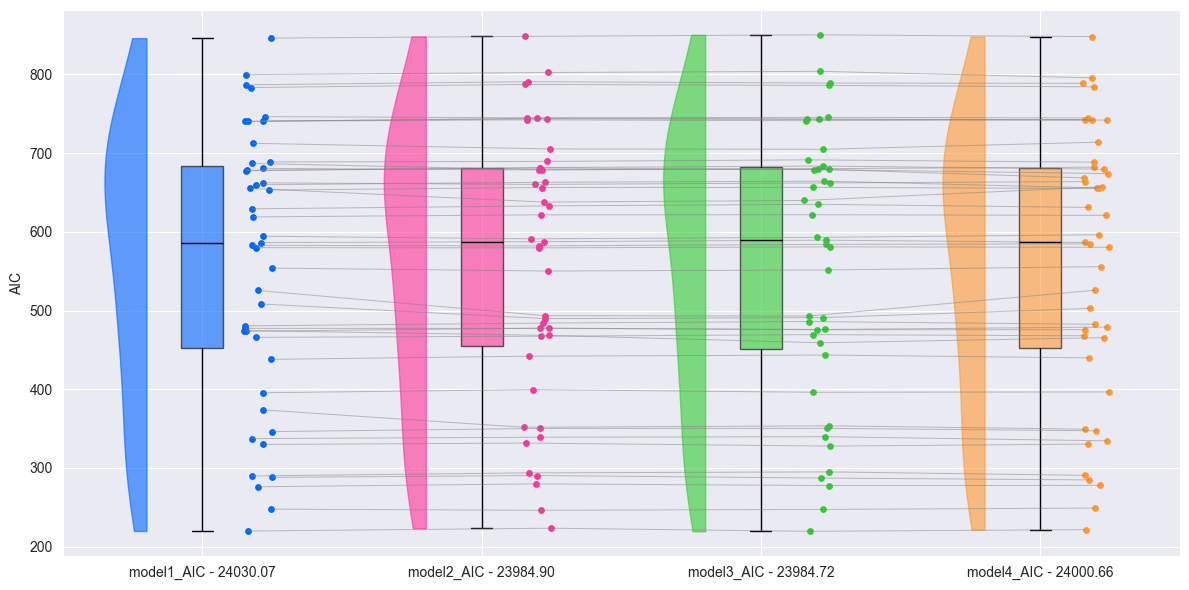

In [115]:
# Remove total column
model_fit_plot = model_fit_combined[model_fit_combined['subject'] != 'total']
model_fit_total = model_fit_combined[model_fit_combined['subject'] == 'total']

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_4_groups(
    model_fit_plot,
    columns=['model1_AIC', 'model2_AIC', 'model3_AIC', 'model4_AIC'],
    labels=[f'model1_AIC - {model_fit_total["model1_AIC"].iloc[0]:.2f}', f'model2_AIC - {model_fit_total["model2_AIC"].iloc[0]:.2f}', f'model3_AIC - {model_fit_total["model3_AIC"].iloc[0]:.2f}', f'model4_AIC - {model_fit_total["model4_AIC"].iloc[0]:.2f}'],
    output_dir=output_dir,
    ylabel_name='AIC',
    plot_name='model_comparison_AIC'
)

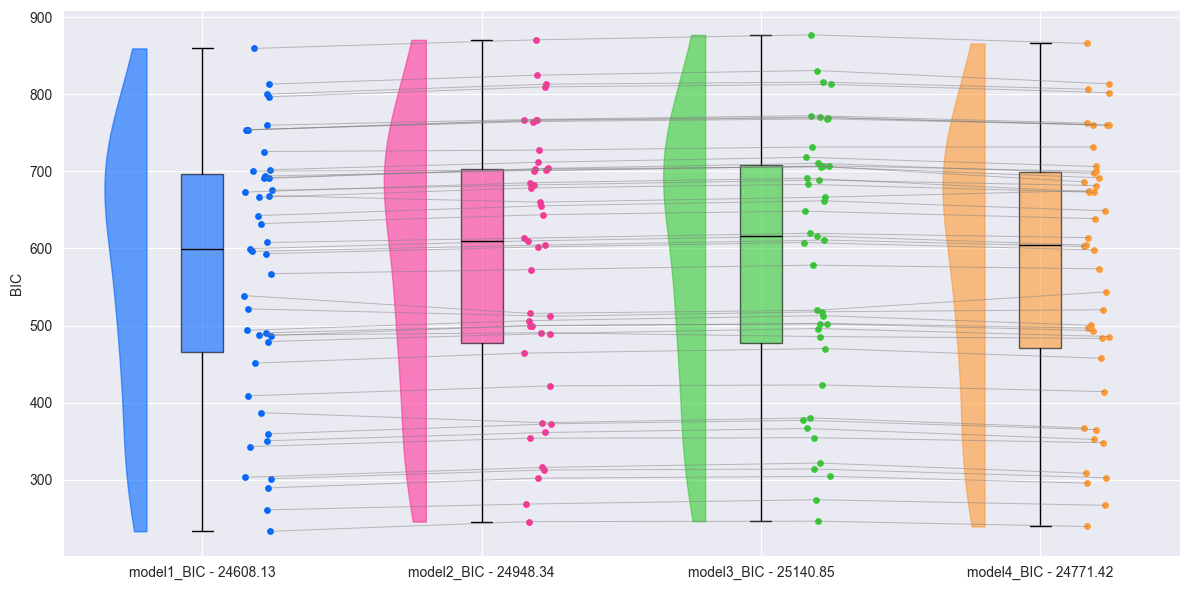

In [116]:
# Remove total column
model_fit_plot = model_fit_combined[model_fit_combined['subject'] != 'total']
model_fit_total = model_fit_combined[model_fit_combined['subject'] == 'total']

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_4_groups(
    model_fit_plot,
    columns=['model1_BIC', 'model2_BIC', 'model3_BIC','model4_BIC'],
    labels=[f'model1_BIC - {model_fit_total["model1_BIC"].iloc[0]:.2f}', f'model2_BIC - {model_fit_total["model2_BIC"].iloc[0]:.2f}', f'model3_BIC - {model_fit_total["model3_BIC"].iloc[0]:.2f}', f'model4_BIC - {model_fit_total["model4_BIC"].iloc[0]:.2f}'],
    output_dir=output_dir,
    ylabel_name='BIC',
    plot_name='model_comparison_BIC'
)

In [117]:
# Print and save
print(model_fit_combined[['subject'] + [col for col in model_fit_combined.columns if 'AIC' in col or 'BIC' in col]])
model_fit_combined.to_csv(f'{preprocessed_model_fit_folder}/model_fit_comparison.csv', index=False)

   subject    model0_AIC    model0_BIC    model1_AIC    model1_BIC  \
0        5    878.696654    905.521451    474.504698    487.917097   
1        5    919.723430    946.640395    579.838668    593.297150   
2        5    914.520703    941.428515    473.691996    487.145902   
3        5    918.366959    945.320398    508.261601    521.738321   
4       10    921.524432    948.459662    525.442959    538.910574   
5       10    914.887806    941.795617    337.367618    350.821524   
6       10    924.121008    951.056238    346.233623    359.701238   
7       10    918.263353    945.161998    276.145267    289.594589   
8       14    907.981043    934.824387    783.189850    796.611522   
9       14    922.989829    949.925059    799.587722    813.055337   
10      14    914.258590    941.175555    786.603032    800.061514   
11      14    919.897569    946.805380    586.315108    599.769013   
12      15    923.664838    950.600068    629.178213    642.645828   
13      15    925.38